 # XGBoost Emotion Classification Analysis

 Comparing TF-IDF, Word2Vec, and GloVe features using XGBoost.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Import your custom modules
from src.data.train_dataset_EDA import load_train_with_features, load_test_with_features
from src.features.tfidf import fit_tfidf_on_clean_text_column
from src.data.dataset import Label_map 
from src.features.glove import build_glove_features, sequences_to_vectors
from src.features.word2vec import build_and_train_w2v_model, get_mean_vectors

 ## 1. Load Data & Distribution

In [4]:
train_df = load_train_with_features()
test_df = load_test_with_features()

print("Train df:", train_df.shape)
print("Test df:", test_df.shape)

train_df.head()


Train df: (16000, 6)
Test df: (2000, 6)


,text,label,char_len,word_len,clean_text,clean_word_len
0,i didnt feel humiliated,0,23,4,i didnt feel humiliated,4
1,i can go from feeling so hopeless to so damned...,0,108,21,i can go from feeling so hopeless to so damned...,21
2,im grabbing a minute to post i feel greedy wrong,3,48,10,im grabbing a minute to post i feel greedy wrong,10
3,i am ever feeling nostalgic about the fireplac...,2,92,18,i am ever feeling nostalgic about the fireplac...,18
4,i am feeling grouchy,3,20,4,i am feeling grouchy,4


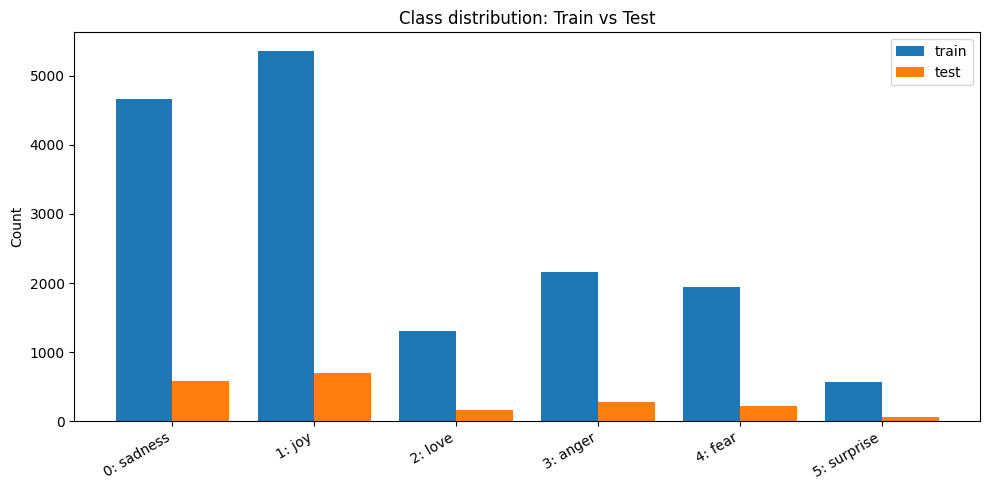

In [5]:
# Visualizing Class Distribution
train_counts = train_df["label"].value_counts().sort_index()
test_counts = test_df["label"].value_counts().sort_index()

labels = [f"{i}: {Label_map[i]}" for i in train_counts.index]
x = np.arange(len(labels))
width = 0.4

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_counts.values, width, label="train")
plt.bar(x + width/2, test_counts.values, width, label="test")
plt.xticks(x, labels, rotation=30, ha="right")
plt.title("Class distribution: Train vs Test")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()


 ## 2. Experiment A: TF-IDF + XGBoost

In [6]:
# 1. Vectorize
# Note: Ensure fit_tfidf_on_clean_text_column uses ngram_range=(1,2) for best results
vectorizer, X_train_tfidf, y_train = fit_tfidf_on_clean_text_column()

X_test_text = test_df["clean_text"]
y_test = test_df["label"].values
X_test_tfidf = vectorizer.transform(X_test_text)

print("X_train (TF-IDF):", X_train_tfidf.shape)
print("X_test  (TF-IDF):", X_test_tfidf.shape)


X_train (TF-IDF): (16000, 20000)
X_test  (TF-IDF): (2000, 20000)


In [7]:
# 2. Train XGBoost
print("Training XGBoost on TF-IDF...")
model_tfidf = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(Label_map),
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    n_jobs=-1,
    random_state=42
)

model_tfidf.fit(X_train_tfidf, y_train)

# 3. Predict
y_pred_tfidf = model_tfidf.predict(X_test_tfidf)


Training XGBoost on TF-IDF...


===== XGBoost (TF-IDF) =====
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       581
           1       0.81      0.93      0.86       695
           2       0.78      0.70      0.74       159
           3       0.93      0.80      0.86       275
           4       0.92      0.80      0.86       224
           5       0.63      0.79      0.70        66

    accuracy                           0.86      2000
   macro avg       0.83      0.82      0.82      2000
weighted avg       0.87      0.86      0.86      2000



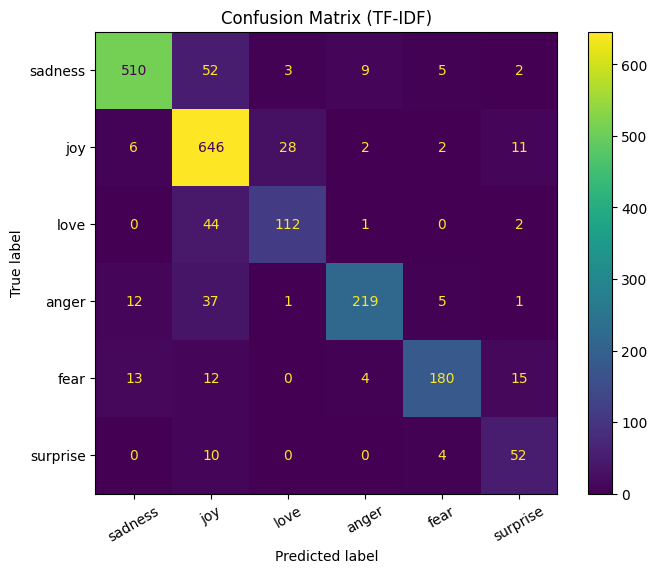

In [8]:
# 4. Evaluate
print("===== XGBoost (TF-IDF) =====")
report_tfidf = classification_report(y_test, y_pred_tfidf, output_dict=True)
print(classification_report(y_test, y_pred_tfidf))

# Confusion Matrix
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, labels=sorted(Label_map.keys()))
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=cm_tfidf, display_labels=[Label_map[i] for i in sorted(Label_map.keys())])

fig, ax = plt.subplots(figsize=(8, 6))
disp_tfidf.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix (TF-IDF)")
plt.show()


 ## 3. Experiment B: Word2Vec + XGBoost

In [9]:
# 1. Train Word2Vec
print("Training Word2Vec...")
w2v_model = build_and_train_w2v_model(
    train_df["clean_text"], 
    vector_size=100, 
    window=5, 
    min_count=2
)
# 2. Vectorize (Mean + Max Pooling)
X_train_w2v = get_mean_vectors(w2v_model, train_df["clean_text"])
X_test_w2v  = get_mean_vectors(w2v_model, test_df["clean_text"])

print("X_train (W2V):", X_train_w2v.shape)


Training Word2Vec...
X_train (W2V): (16000, 200)


In [10]:
# 3. Train XGBoost
print("Training XGBoost on Word2Vec...")
model_w2v = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(Label_map),
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

model_w2v.fit(X_train_w2v, y_train)
y_pred_w2v = model_w2v.predict(X_test_w2v)


Training XGBoost on Word2Vec...


===== XGBoost (Word2Vec) =====
              precision    recall  f1-score   support

           0       0.54      0.70      0.61       581
           1       0.60      0.78      0.68       695
           2       0.52      0.20      0.29       159
           3       0.53      0.25      0.34       275
           4       0.54      0.32      0.40       224
           5       0.45      0.08      0.13        66

    accuracy                           0.56      2000
   macro avg       0.53      0.39      0.41      2000
weighted avg       0.55      0.56      0.53      2000



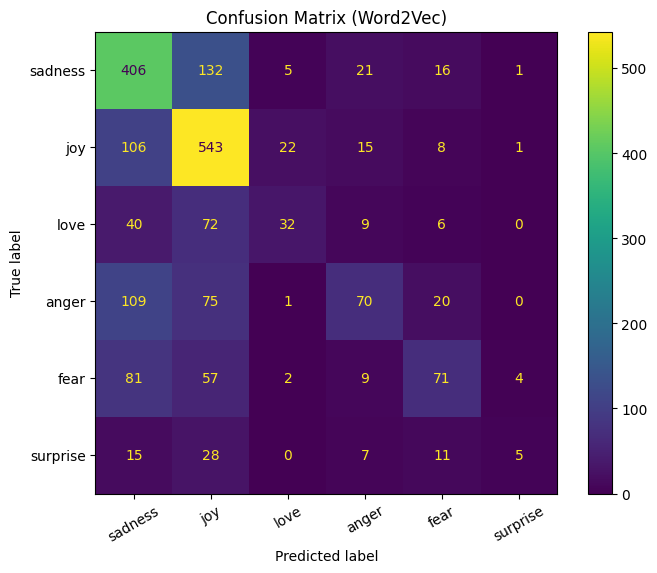

In [11]:
# 4. Evaluate
print("===== XGBoost (Word2Vec) =====")
print(classification_report(y_test, y_pred_w2v))

cm_w2v = confusion_matrix(y_test, y_pred_w2v, labels=sorted(Label_map.keys()))
disp_w2v = ConfusionMatrixDisplay(confusion_matrix=cm_w2v, display_labels=[Label_map[i] for i in sorted(Label_map.keys())])

fig, ax = plt.subplots(figsize=(8, 6))
disp_w2v.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix (Word2Vec)")
plt.show()


 ## 4. Experiment C: GloVe + XGBoost

In [12]:
# 1. Load Sequences
X_train_seq, y_train, X_test_seq, y_test, tokenizer, embedding_matrix, num_words = (
    build_glove_features()
)

# 2. Convert to Vectors (Mean + Max Pooling)
X_train_glove = sequences_to_vectors(X_train_seq, embedding_matrix)
X_test_glove  = sequences_to_vectors(X_test_seq, embedding_matrix)

print("X_train (GloVe):", X_train_glove.shape)


X_train (GloVe): (16000, 200)


In [13]:
# 3. Train XGBoost
# Note: XGBoost is robust to scaling, so we skip StandardScaler here
print("Training XGBoost on GloVe...")
model_glove = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=len(Label_map),
    n_estimators=100,
    n_jobs=-1,
    random_state=42
)

model_glove.fit(X_train_glove, y_train)
y_pred_glove = model_glove.predict(X_test_glove)


Training XGBoost on GloVe...


===== XGBoost (GloVe) =====
              precision    recall  f1-score   support

           0       0.76      0.78      0.77       581
           1       0.70      0.85      0.77       695
           2       0.71      0.50      0.59       159
           3       0.82      0.67      0.73       275
           4       0.79      0.65      0.71       224
           5       0.68      0.39      0.50        66

    accuracy                           0.74      2000
   macro avg       0.74      0.64      0.68      2000
weighted avg       0.74      0.74      0.73      2000



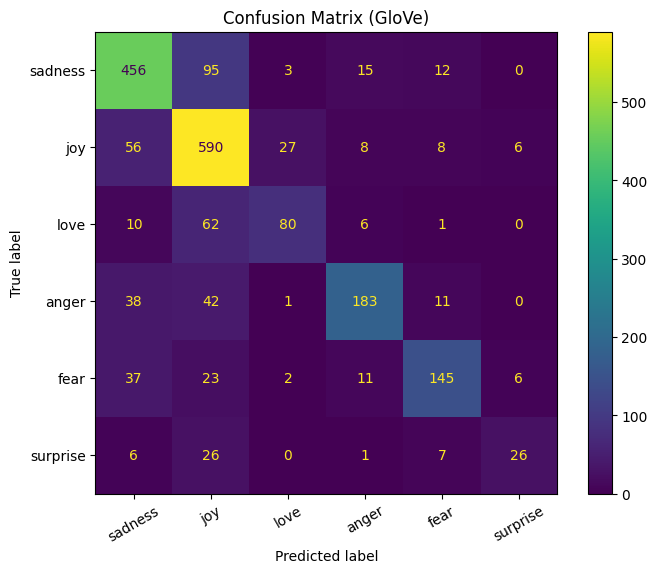

In [14]:
# 4. Evaluate
print("===== XGBoost (GloVe) =====")
print(classification_report(y_test, y_pred_glove))

cm_glove = confusion_matrix(y_test, y_pred_glove, labels=sorted(Label_map.keys()))
disp_glove = ConfusionMatrixDisplay(confusion_matrix=cm_glove, display_labels=[Label_map[i] for i in sorted(Label_map.keys())])

fig, ax = plt.subplots(figsize=(8, 6))
disp_glove.plot(ax=ax, xticks_rotation=30)
plt.title("Confusion Matrix (GloVe)")
plt.show()


 ## 5. Final Comparison

TF-IDF Accuracy:   85.95%
Word2Vec Accuracy: 56.35%
GloVe Accuracy:    74.00%


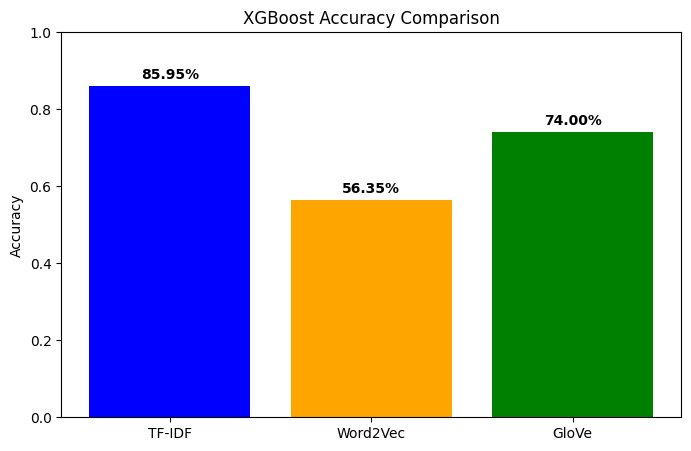

In [15]:
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
acc_w2v   = accuracy_score(y_test, y_pred_w2v)
acc_glove = accuracy_score(y_test, y_pred_glove)

print(f"TF-IDF Accuracy:   {acc_tfidf:.2%}")
print(f"Word2Vec Accuracy: {acc_w2v:.2%}")
print(f"GloVe Accuracy:    {acc_glove:.2%}")

# Plot
results = pd.DataFrame({
    'Model': ['TF-IDF', 'Word2Vec', 'GloVe'],
    'Accuracy': [acc_tfidf, acc_w2v, acc_glove]
})

plt.figure(figsize=(8, 5))
plt.bar(results['Model'], results['Accuracy'], color=['blue', 'orange', 'green'])
plt.ylim(0, 1.0)
plt.title("XGBoost Accuracy Comparison")
plt.ylabel("Accuracy")
for i, v in enumerate(results['Accuracy']):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center', fontweight='bold')
plt.show()